# Fase 4: Análisis exploratorio de datos y visualización
---
Este cuaderno tiene como objetivo la exploración visual de los resultados.

En esta etapa de validación, se comprobó empíricamente si las hipótesis lingüísticas y emocionales se reflejan en los datos numéricos. El análisis se divide en tres dimensiones:
1. **Estilometría y complejidad léxica.**
2. **Distribución temática y n-gramas.**
3. **Análisis longitudinal del sentimiento y la emoción.**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast

import math
import json

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv('../data/processed/taylor_swift_metrics.csv')

In [5]:
album_order = [
    "Taylor Swift",
    "Fearless (Taylor’s Version)",
    "Speak Now (Taylor’s Version)",
    "Red (Taylor’s Version)",
    "1989 (Taylor’s Version)",
    "reputation",
    "Lover",
    "folklore",
    "evermore",
    "Midnights",
    "THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY",
    "The Life Of A Showgirl"
]

In [6]:
# códigos de colores sacados de https://www.wikihow.com/Taylor-Swift-Eras-Colors

eras_colors = {
    "Taylor Swift": "#9ccfa4",
    "Fearless (Taylor’s Version)": "#f2c17d",
    "Speak Now (Taylor’s Version)": "#cfa6d0",
    "Red (Taylor’s Version)": "#7e303b",
    "1989 (Taylor’s Version)": "#b2e5f9",
    "reputation": "#000000",
    "Lover": "#f8b4d2",
    "folklore": "#d1d1d1",
    "evermore": "#c6a78c",
    "Midnights": "#283149",
    "THE TORTURED POETS DEPARTMENT: THE ANTHOLOGY": "#ffffff",
    "The Life Of A Showgirl": "#e35829"
}

In [7]:
df_main = df[df['album'].isin(album_order)].copy()

### 4.1 Criterios estilísticos
#### ¿Cómo ha evolucionado la forma de escribir de Taylor Swift?

C:\Users\andre\AppData\Local\Temp\ipykernel_29116\1321873424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='album', y='type_token_ratio', data=df_main, order=album_order, palette=eras_colors)


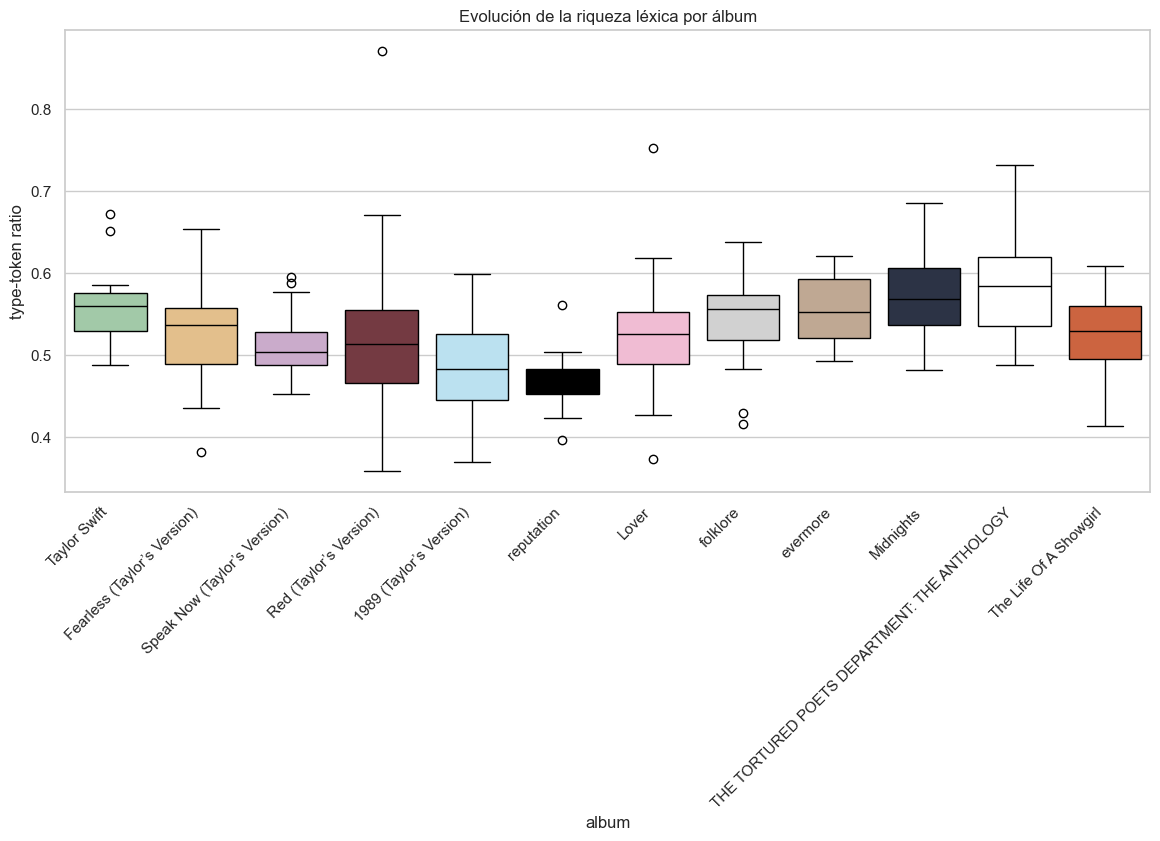

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='album', y='type_token_ratio', data=df_main, order=album_order, palette=eras_colors)
plt.xticks(rotation=45, ha='right')
plt.title("Evolución de la riqueza léxica por álbum")
plt.ylabel("type-token ratio") # más alto = menos repetitivo
plt.show()

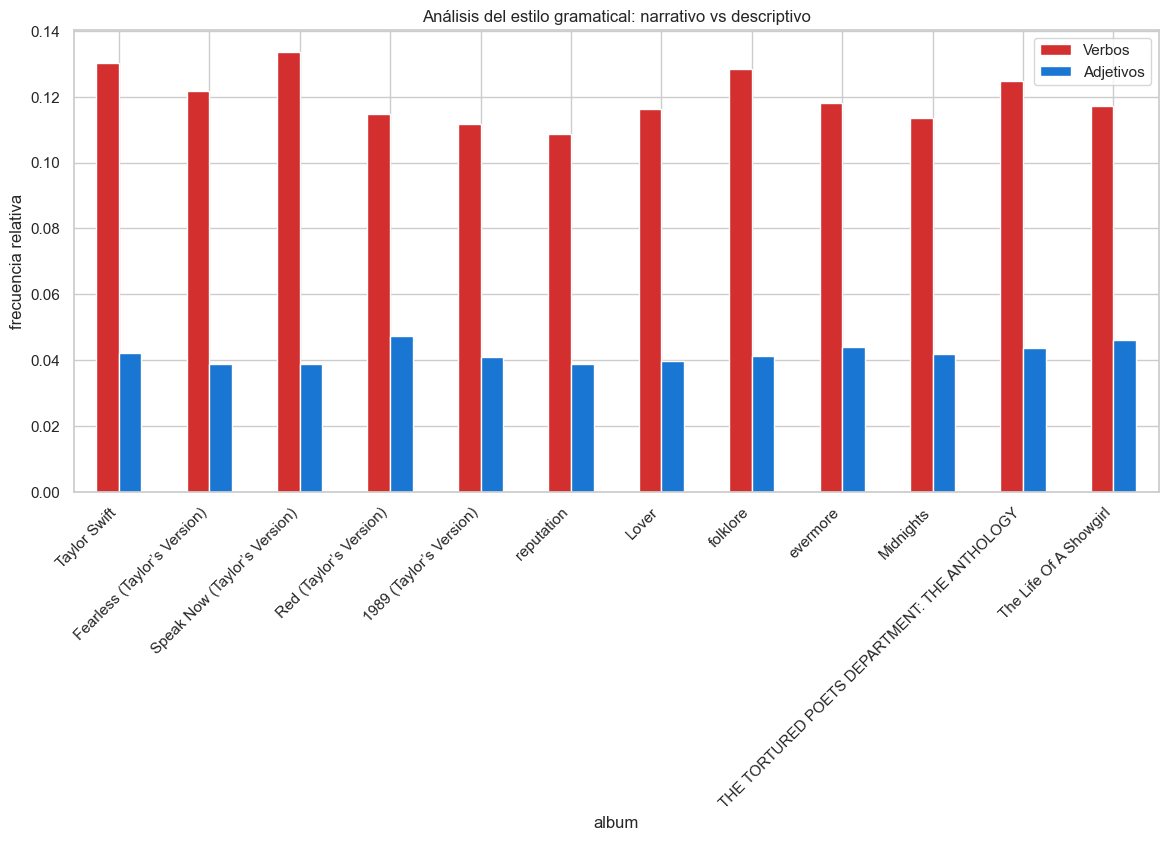

In [9]:
grouped_grammar = df_main.groupby('album')[['verb_ratio', 'adj_ratio']].mean().reindex(album_order)

grouped_grammar.plot(kind='bar', figsize=(14, 6), color=['#d32f2f', '#1976d2'])
plt.title("Análisis del estilo gramatical: narrativo vs descriptivo")
plt.xticks(rotation=45, ha='right')
plt.ylabel("frecuencia relativa")
plt.legend(["Verbos", "Adjetivos"])
plt.show()

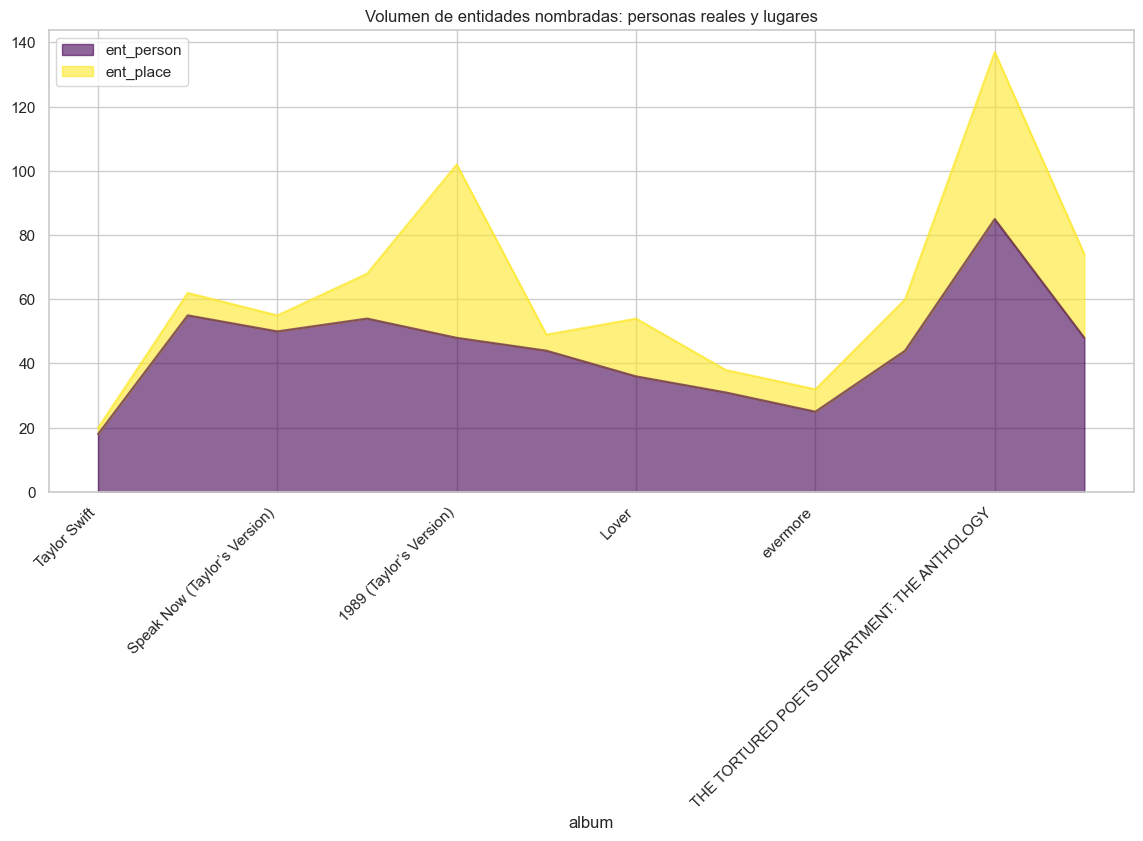

In [10]:
ner_data = df_main.groupby('album')[['ent_person', 'ent_place']].sum().reindex(album_order)
ner_data.plot(kind='area', stacked=True, figsize=(14, 6), alpha=0.6, colormap='viridis')
plt.title("Volumen de entidades nombradas: personas reales y lugares")
plt.xticks(rotation=45, ha='right')
plt.show()

### 4.2 Análisis de sentimientos y emociones
#### Sobre los textos completos

C:\Users\andre\AppData\Local\Temp\ipykernel_29116\2488195156.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='album', y='sentiment_polarity', data=df_main, order=album_order, palette=eras_colors, inner="quartile") # TextBlob


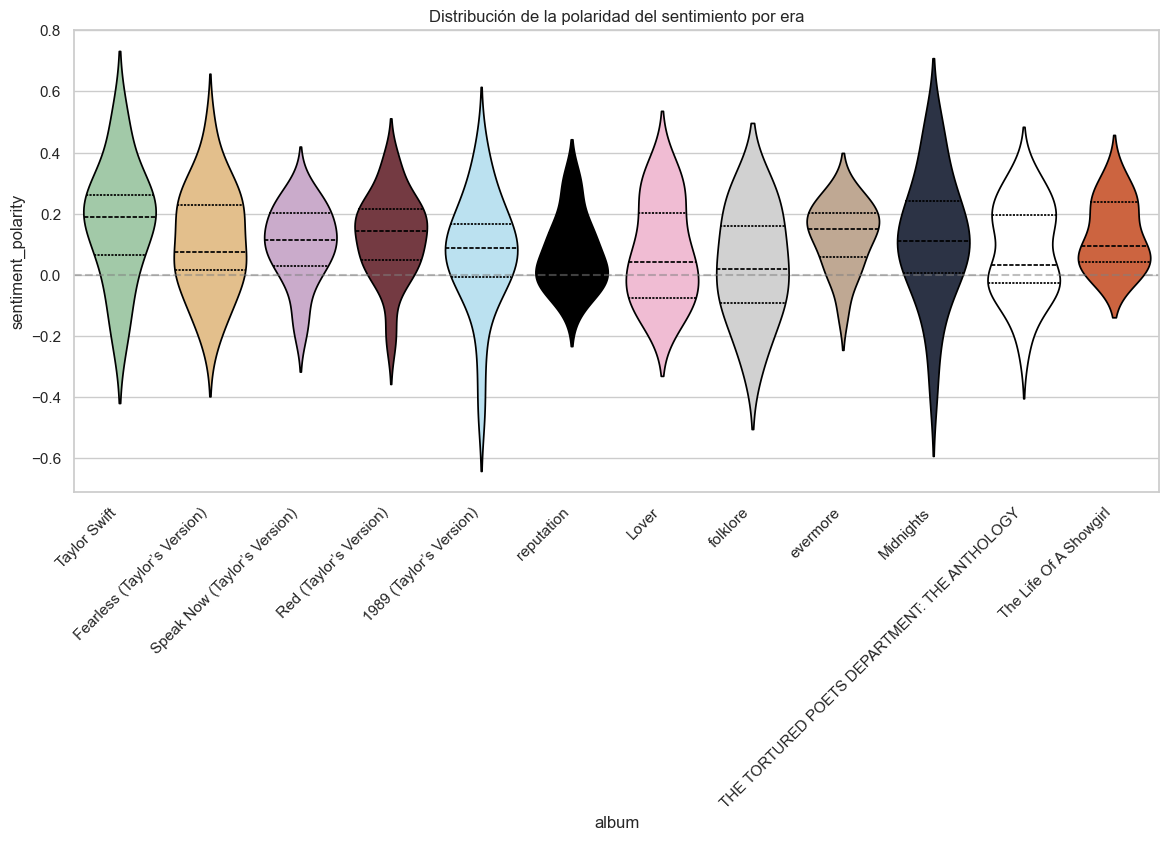

In [11]:
plt.figure(figsize=(14, 6))
sns.violinplot(x='album', y='sentiment_polarity', data=df_main, order=album_order, palette=eras_colors, inner="quartile") # TextBlob
plt.axhline(0, color='gray', linestyle='--', alpha=0.5) # línea de neutralidad
plt.title("Distribución de la polaridad del sentimiento por era")
plt.xticks(rotation=45, ha='right')
plt.show()

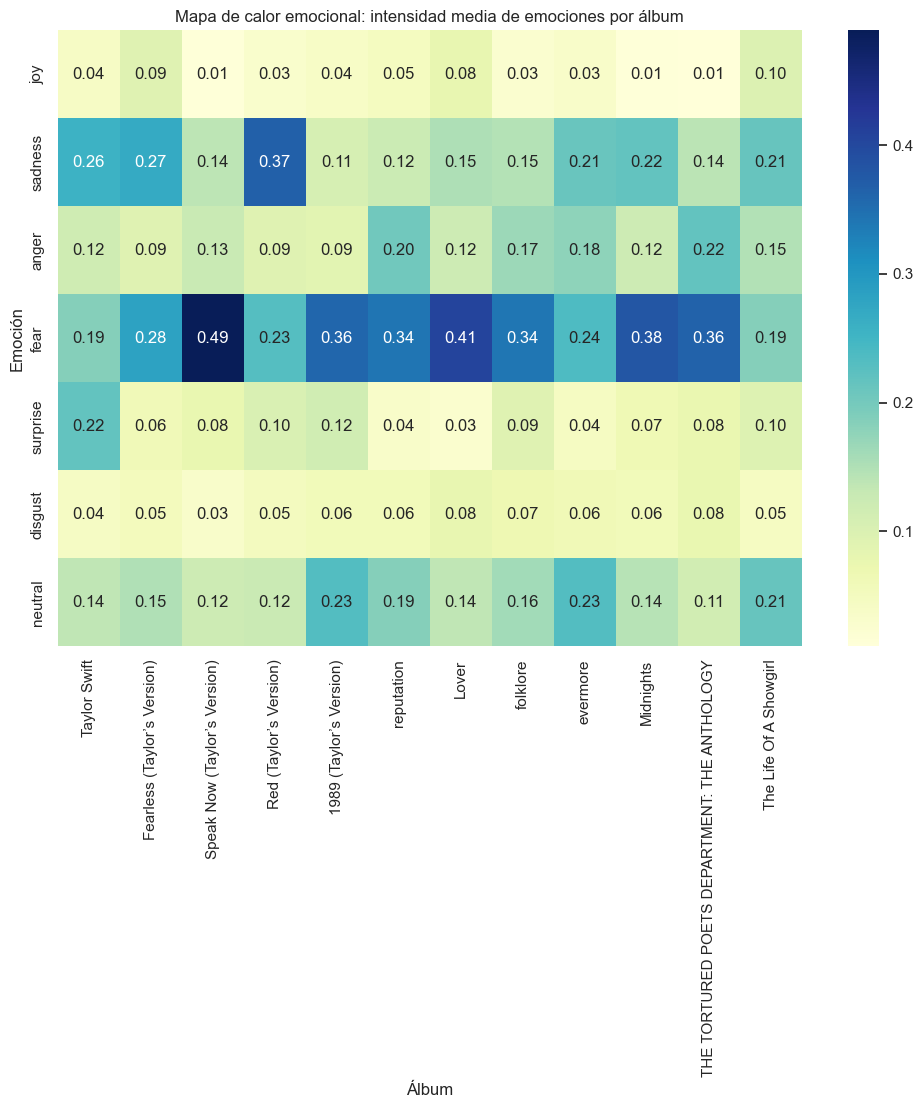

In [12]:
emotions = ['joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust', 'neutral']
album_emotions = df_main.groupby('album')[emotions].mean().reindex(album_order)

plt.figure(figsize=(12, 8))
sns.heatmap(album_emotions.T, cmap='YlGnBu', annot=True, fmt=".2f")
plt.title("Mapa de calor emocional: intensidad media de emociones por álbum") # RoBERTa
plt.xlabel("Álbum")
plt.ylabel("Emoción")
plt.show()

#### Sobre fragmentos

In [13]:
from transformers import pipeline

classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None, truncation=True)

def plot_emotional_arc(song_title, n_chunks=10):
    row = df[df['title'] == song_title]
    if row.empty:
        print(f"Canción '{song_title}' no encontrada.")
        return
    
    lyrics = row['lyrics_full'].values[0]

    words = lyrics.split()
    chunk_size = len(words) // n_chunks
    chunks = [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]
    
    if len(chunks) > n_chunks:
        chunks = chunks[:n_chunks] # ajuste por si el último chunk es muy pequeño

    joy_scores = []
    sadness_scores = []
    anger_scores = []

    for chunk in chunks:
        if not chunk.strip():
            continue
        preds = classifier(chunk)[0]
        scores = {d['label']: d['score'] for d in preds}

        joy_scores.append(scores.get('joy', 0))
        sadness_scores.append(scores.get('sadness', 0))
        anger_scores.append(scores.get('anger', 0))

    x = range(1, len(joy_scores) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(x, joy_scores, label='Joy', color='green', linewidth=2, marker='o')
    plt.plot(x, sadness_scores, label='Sadness', color='blue', linewidth=2, marker='o')
    plt.plot(x, anger_scores, label='Anger', color='red', linewidth=2, marker='o')

    plt.title(f"Arco emocional narrativo de '{song_title}'")
    plt.xlabel("Progresión de la canción")
    plt.ylabel("Intensidad emocional")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


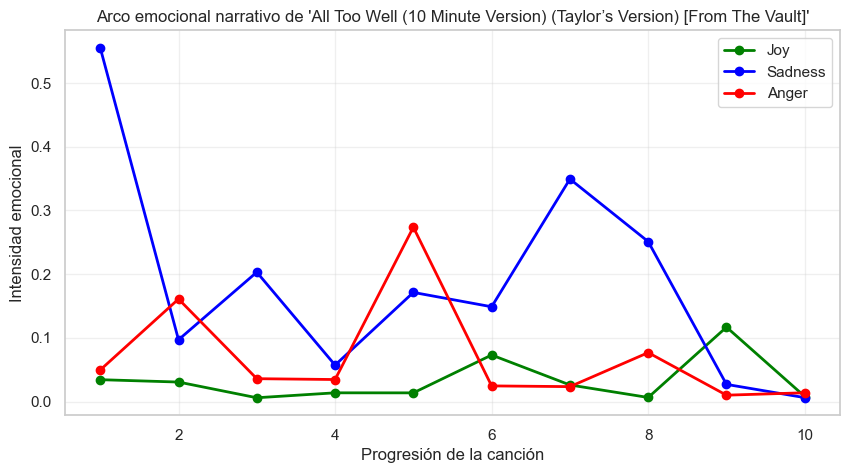

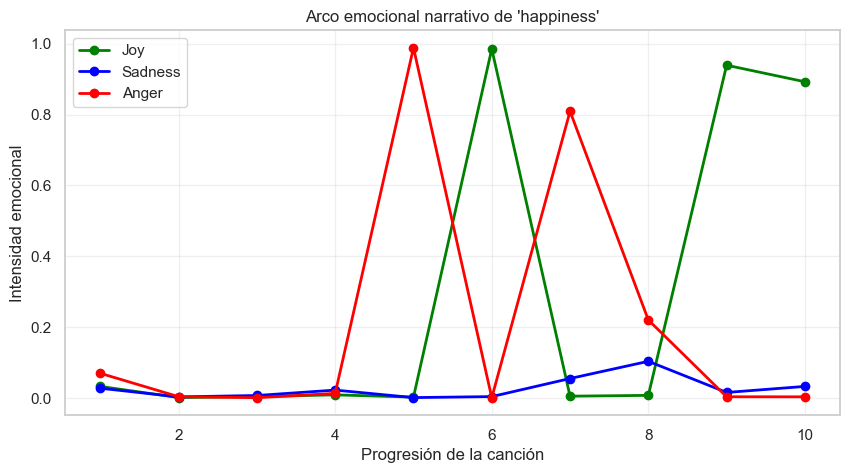

In [ ]:
# EJEMPLOS

# canción narrativa larga
plot_emotional_arc("All Too Well (10 Minute Version) (Taylor’s Version) [From The Vault]")

# canción con cambio de tono
plot_emotional_arc("happiness")

In [15]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

custom_labels = [
    "heartbreak",
    "falling in love",
    "revenge",
    "nostalgia",
    "self-love",
    "grief",
    "fiction"
]

test_lyrics = """
Nice to meet you, where you been?
I could show you incredible things
Magic, madness, heaven, sin
Saw you there and I thought
"Oh, my God, look at that face"
You look like my next mistake
Love's a game, wanna play?
"""

result = classifier(test_lyrics, candidate_labels=custom_labels)

print("Canción: Blank Space\nTop 3 etiquetas detectadas")
for i in range(3):
    print(f"{i+1}. {result['labels'][i]}: {result['scores'][i]:.4f}")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Canción: Blank Space
Top 3 etiquetas detectadas
1. falling in love: 0.6225
2. self-love: 0.1227
3. fiction: 0.0705


In [16]:
classifier_standard = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None)

classifier_zeroshot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

test_lyrics = """
There'll be happiness after you
But there was happiness because of you
Both of these things can be true
There is happiness
Past the blood and bruise
Past the curses and cries
Beyond the terror in the nightfall
"""

res_std = classifier_standard(test_lyrics)[0]
res_std = sorted(res_std, key=lambda x: x['score'], reverse=True)
print(f"Emoción detectada: {res_std[0]['label']} ({res_std[0]['score']:.4f})")

custom_labels = [
    "joy",
    "anger",
    "sadness",
    "fear",
    "neutral",
    "disgust",
    "surprise",
    "heartbreak",
    "falling in love",
    "revenge",
    "nostalgia",
    "self-love",
    "grief",
    "fiction"
]

res_zero = classifier_zeroshot(test_lyrics, candidate_labels=custom_labels)
print("Ranking de probabilidad:")
for label, score in zip(res_zero['labels'], res_zero['scores']):
    print(f"- {label}: {score:.4f}")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Emoción detectada: fear (0.8712)
Ranking de probabilidad:
- surprise: 0.2619
- joy: 0.1911
- fear: 0.1060
- neutral: 0.0772
- self-love: 0.0745
- revenge: 0.0649
- falling in love: 0.0427
- nostalgia: 0.0420
- anger: 0.0370
- grief: 0.0346
- heartbreak: 0.0228
- fiction: 0.0211
- sadness: 0.0127
- disgust: 0.0116


Analizando 'happiness' con Zero-Shot...


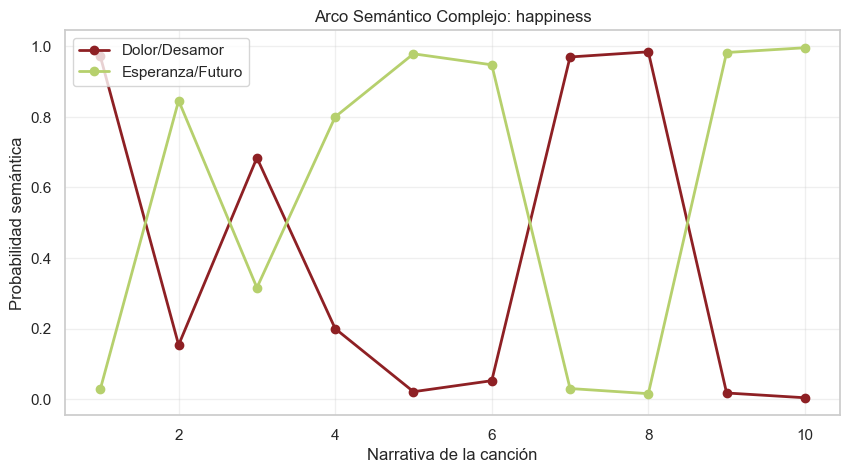

In [17]:
def plot_complex_arc(song_title, n_chunks=10):
    row = df[df['title'] == song_title]
    if row.empty:
        return
    lyrics = row['lyrics_full'].values[0]

    words = lyrics.split()
    chunk_size = len(words) // n_chunks
    chunks = [" ".join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]
    if len(chunks) > n_chunks:
        chunks = chunks[:n_chunks]

    labels = ["heartbreak", "hope"]

    scores_label1 = []
    scores_label2 = []

    print(f"Analizando '{song_title}' con Zero-Shot...")

    for chunk in chunks:
        result = classifier_zeroshot(chunk, candidate_labels=labels)
        idx_1 = result['labels'].index(labels[0])
        idx_2 = result['labels'].index(labels[1])

        scores_label1.append(result['scores'][idx_1])
        scores_label2.append(result['scores'][idx_2])

    x = range(1, len(scores_label1) + 1)
    plt.figure(figsize=(10, 5))

    plt.plot(x, scores_label1, label='Dolor/Desamor', color='#8E2024', linewidth=2, marker='o')
    plt.plot(x, scores_label2, label='Esperanza/Futuro', color='#B6D06D', linewidth=2, marker='o')

    plt.title(f"Arco Semántico Complejo: {song_title}")
    plt.xlabel("Narrativa de la canción")
    plt.ylabel("Probabilidad semántica")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_complex_arc("happiness")

In [18]:
classifier_standard = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None)

classifier_zeroshot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

test_lyrics = """
There'll be happiness after you
But there was happiness because of you
Both of these things can be true
There is happiness
Past the blood and bruise
Past the curses and cries
Beyond the terror in the nightfall
"""

res_std = classifier_standard(test_lyrics)[0]
res_std = sorted(res_std, key=lambda x: x['score'], reverse=True)
print(f"Emoción detectada: {res_std[0]['label']} ({res_std[0]['score']:.4f})")

custom_labels = [
    "joy",
    "anger",
    "sadness",
    "fear",
    "neutral",
    "disgust",
    "surprise",
    "heartbreak",
    "falling in love",
    "revenge",
    "nostalgia",
    "self-love",
    "grief",
    "fiction",
    "bittersweet acceptance",
    "hope",
    "healing from trauma",
    "pure joy",
    "physical fear"
]

res_zero = classifier_zeroshot(test_lyrics, candidate_labels=custom_labels)
print("Ranking de probabilidad:")
for label, score in zip(res_zero['labels'], res_zero['scores']):
    print(f"- {label}: {score:.4f}")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Emoción detectada: fear (0.8712)
Ranking de probabilidad:
- bittersweet acceptance: 0.2448
- physical fear: 0.1982
- healing from trauma: 0.1130
- hope: 0.0928
- surprise: 0.0859
- joy: 0.0627
- fear: 0.0348
- neutral: 0.0253
- self-love: 0.0244
- pure joy: 0.0233
- revenge: 0.0213
- falling in love: 0.0140
- nostalgia: 0.0138
- anger: 0.0121
- grief: 0.0113
- heartbreak: 0.0075
- fiction: 0.0069
- sadness: 0.0042
- disgust: 0.0038


### 4.3 Distribución de la longitud del texto (`word count`)

C:\Users\andre\AppData\Local\Temp\ipykernel_29116\2135913444.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


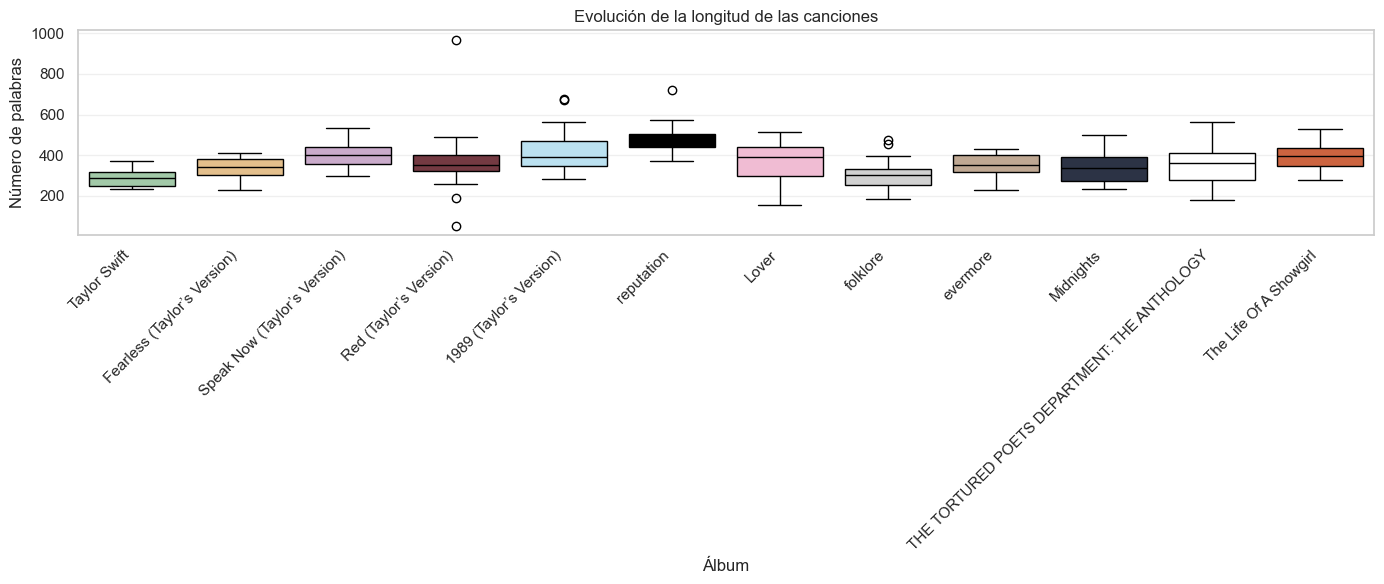

In [19]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_main,
    x='album',
    y='word_count',
    order=album_order,
    palette=eras_colors,
    showfliers=True
)

plt.title('Evolución de la longitud de las canciones')
plt.xlabel('Álbum', fontsize=12)
plt.ylabel('Número de palabras', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 Distribución general de temáticas / emociones

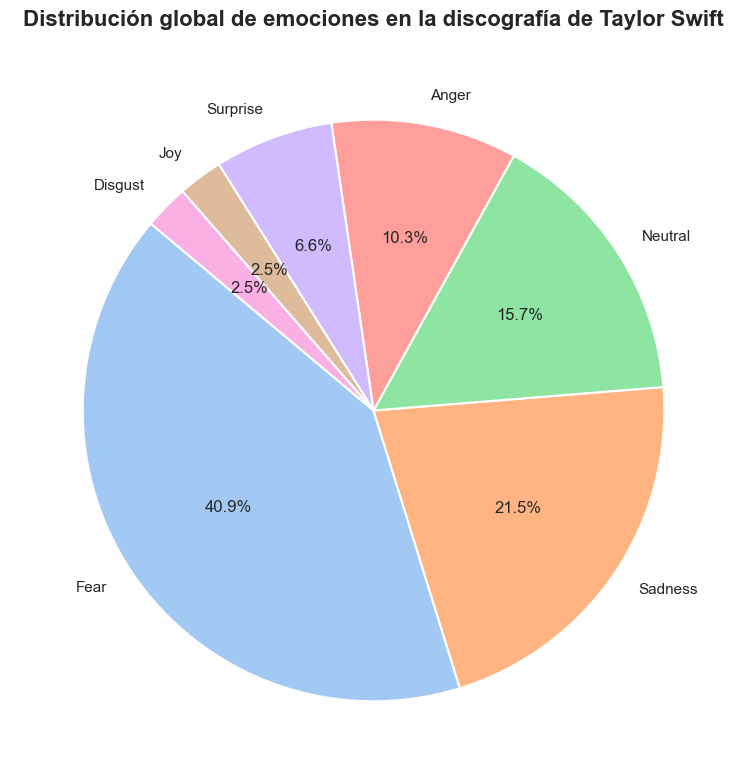

In [20]:
plt.figure(figsize=(8, 8))

emotion_count = df_main['dominant_emotion'].value_counts()
colors_pie = sns.color_palette("pastel")[0:len(emotion_count)]

plt.pie(
    emotion_count,
    labels=emotion_count.index.str.title(),
    colors=colors_pie,
    autopct='%1.1f%%', # muestra el porcentaje
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Distribución global de emociones en la discografía de Taylor Swift', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4.5 Frecuencia de palabras y n-gramas

In [21]:
custom_stopwords = list(ENGLISH_STOP_WORDS) + [
    'oh', 'yeah', 'cause', 'wanna', 'gonna', 'gotta', 'like', 'just', 'got', 'woah',
    'know', 'don', 'll', 've', 're', 'ain', 'ooh', 'ah', 'ha', 'la', 'eh', 'na', 'til',
    'im', 'm', 'did', 'didn', 'say', 'said', 'let', 'tell', 'way', 'make', 'wouldve',
    'uh', 'want', 'need', 'feel', 'think', 'right', 'time', 'thing', 'look', 'come',
    'dont', 'youre', 'ill', 'ive', 'hes', 'shes', 'were', 'theres', 'cant', 'wont',
    'didnt', 'id', 'youd', 'shouldve', 'isnt', 'youve', 'arent', 'wasnt', 'werent',
    'hadnt', 'doesnt', 'couldve', 'theyre', 'hey', 'thats', 'hasnt', 'isn', 'mm', 'won',
    'wasn', 'weren', 'doesn', 'hasn', 'hadn', 'couldn', 'wouldn', 'shouldn', 'aren',
    'somethin', 'nothin', 'bout', 'em', 'things', 'waitin', 'youll', 'theyll', 'ohohoh'
]

def get_top_n_words(corpus, n=None, ngram_range=(1, 1)):
    vec = CountVectorizer(stop_words=custom_stopwords, ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

clean_lyrics = df_main['lyrics_unique'].dropna().astype(str)

C:\Users\andre\AppData\Local\Temp\ipykernel_29116\1359489044.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_words, x='count', y='word', palette='Purples_r')


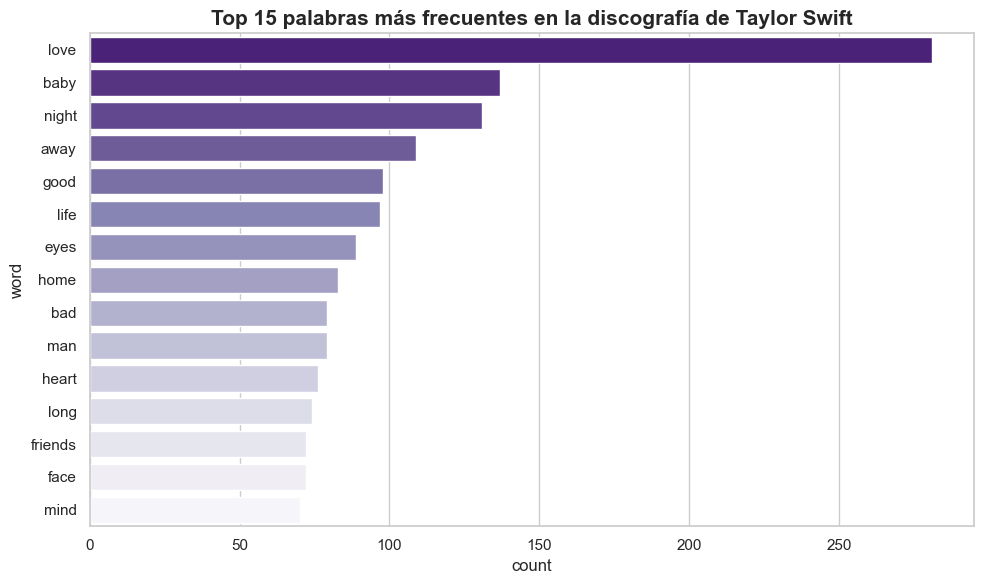

In [22]:
top_words_global = get_top_n_words(clean_lyrics, n=15, ngram_range=(1,1))
df_words = pd.DataFrame(top_words_global, columns=['word', 'count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_words, x='count', y='word', palette='Purples_r')
plt.title('Top 15 palabras más frecuentes en la discografía de Taylor Swift', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_29116\958082563.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bigrams, x='count', y='bigram', palette='Blues_r')


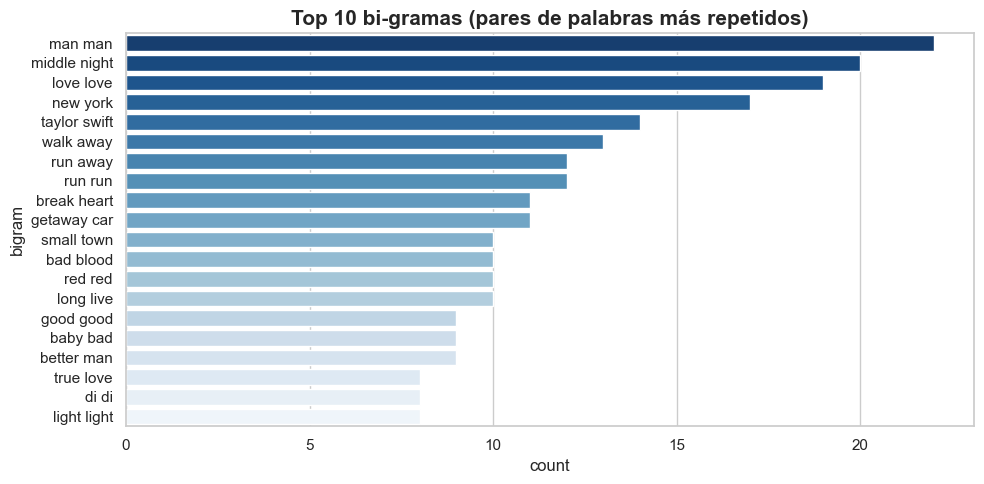

In [23]:
top_bigrams = get_top_n_words(clean_lyrics, n=20, ngram_range=(2,2))
df_bigrams = pd.DataFrame(top_bigrams, columns=['bigram', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=df_bigrams, x='count', y='bigram', palette='Blues_r')
plt.title('Top 10 bi-gramas (pares de palabras más repetidos)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

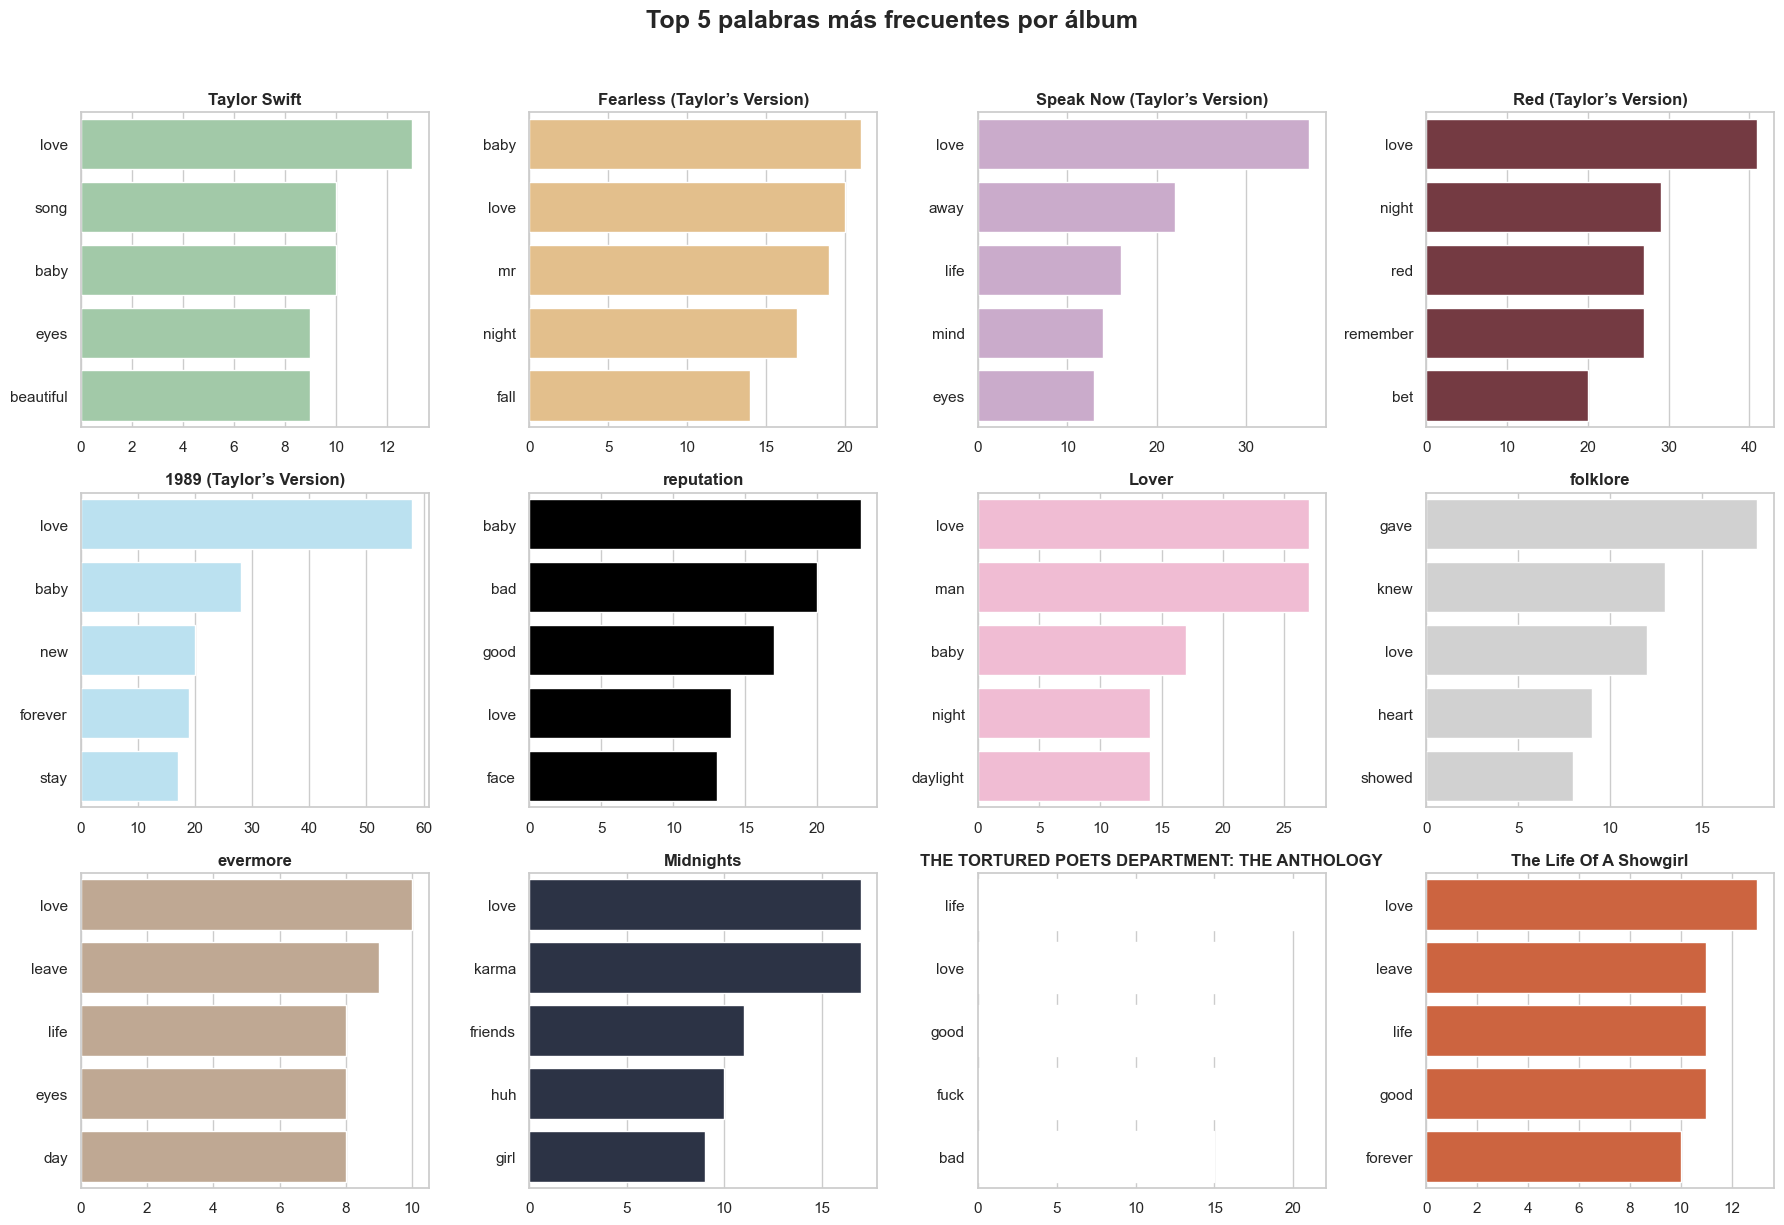

In [24]:
n_albums = len(album_order)
cols = 4
rows = math.ceil(n_albums / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, album in enumerate(album_order):
    album_lyrics = df_main[df_main['album'] == album]['lyrics_unique'].dropna().astype(str)

    if not album_lyrics.empty:
        top_album = get_top_n_words(album_lyrics, n=5, ngram_range=(1,1))
        df_alb = pd.DataFrame(top_album, columns=['word', 'count'])

        color = eras_colors.get(album, '#cccccc')

        sns.barplot(data=df_alb, x='count', y='word', ax=axes[i], color=color)
        axes[i].set_title(album, fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 palabras más frecuentes por álbum', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Nubes de palabras por álbum

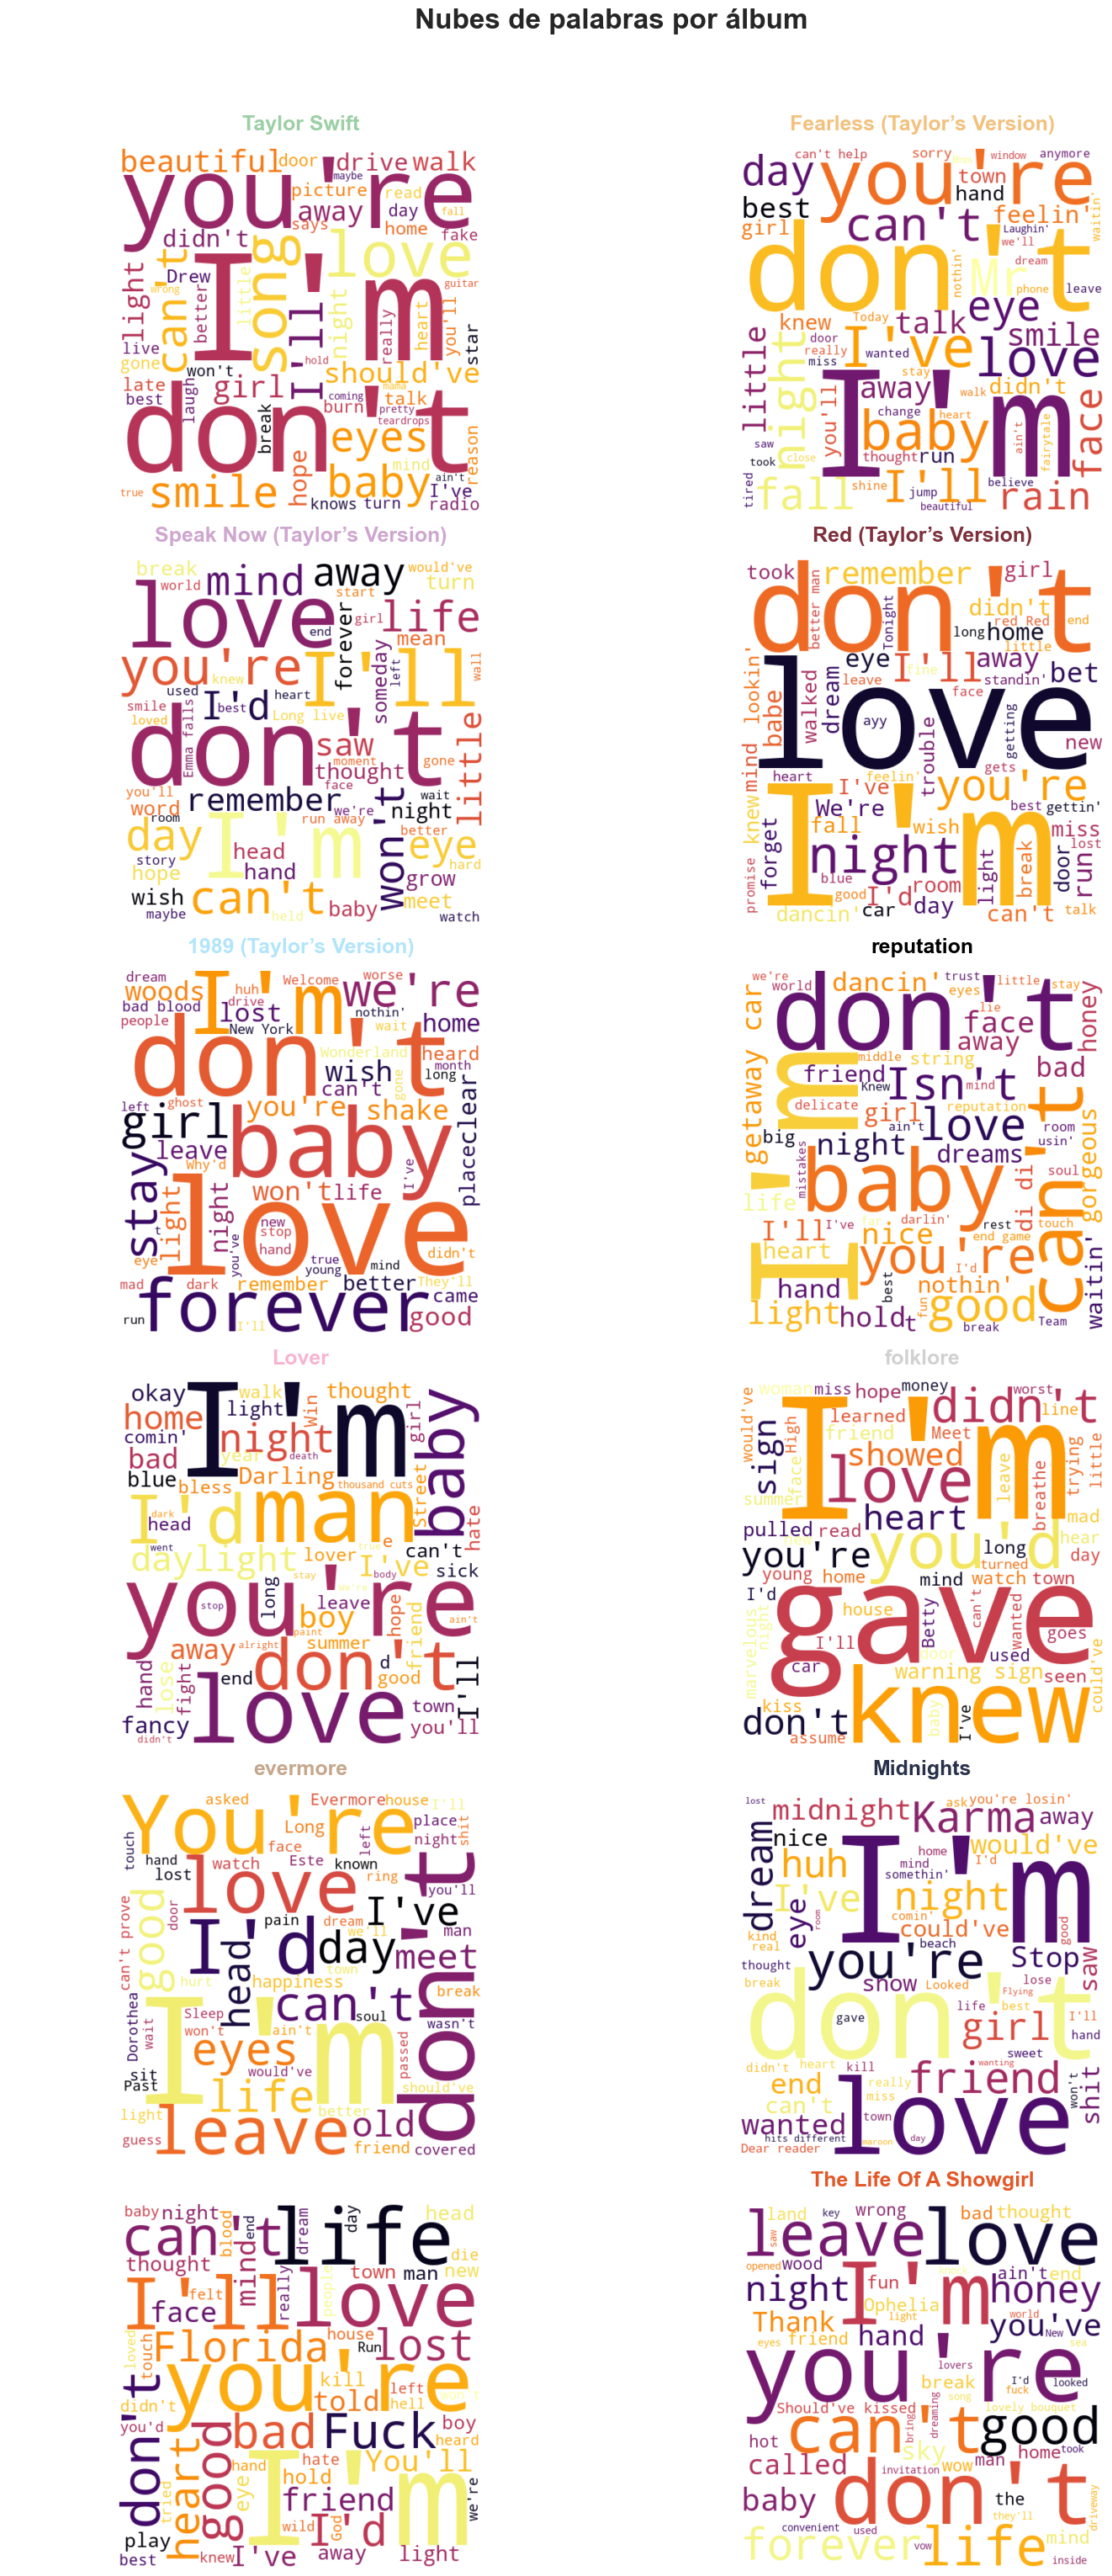

In [25]:
n_albums = len(album_order)
cols = 2
rows = math.ceil(n_albums / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, album in enumerate(album_order):
    album_text = " ".join(df_main[df_main['album'] == album]['lyrics_unique'].dropna().astype(str))

    if len(album_text.strip()) > 0:
        wordcloud = WordCloud(
            width=500, height=500,
            background_color='white',
            stopwords=custom_stopwords,
            max_words=60,
            colormap='inferno'
        ).generate(album_text)

        axes[i].imshow(wordcloud, interpolation='bilinear')
    
    color_title = eras_colors.get(album, 'black')
    axes[i].set_title(album, fontsize=18, fontweight='bold', color=color_title, pad=15)
    axes[i].axis('off') # ocultar los bordes y ejes

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Nubes de palabras por álbum', fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Evaluación de los Transformers
Tras analizar las métricas básicas, se procedió a visualizar los resultados de la inferencia matemática de los modelos `facebook/bart-large-mnli` (para temáticas) y `samlowe/roberta-base-go_emotions` para emociones. El objetivo de esta sección es observar la evolución de la narrativa del artista a lo largo de los años y entender cómo cambia la paleta emocional de cada era musical.

#### Distribución general de temáticas y emociones

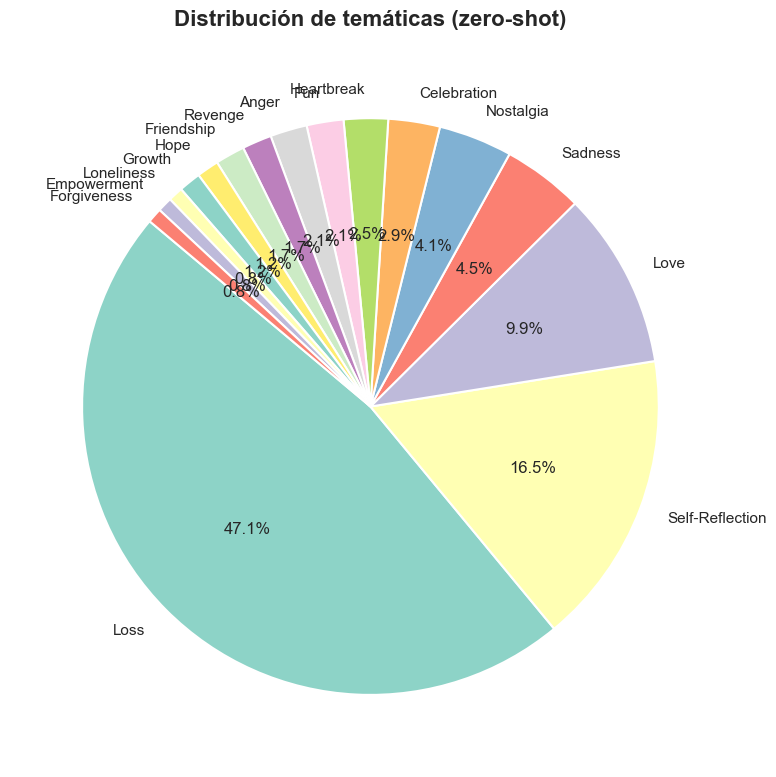

In [26]:
plt.figure(figsize=(8, 8))

theme_count = df_main['theme_zeroshot'].value_counts()

plt.pie(
    theme_count,
    labels=theme_count.index.str.title(),
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set3"),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Distribución de temáticas (zero-shot)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

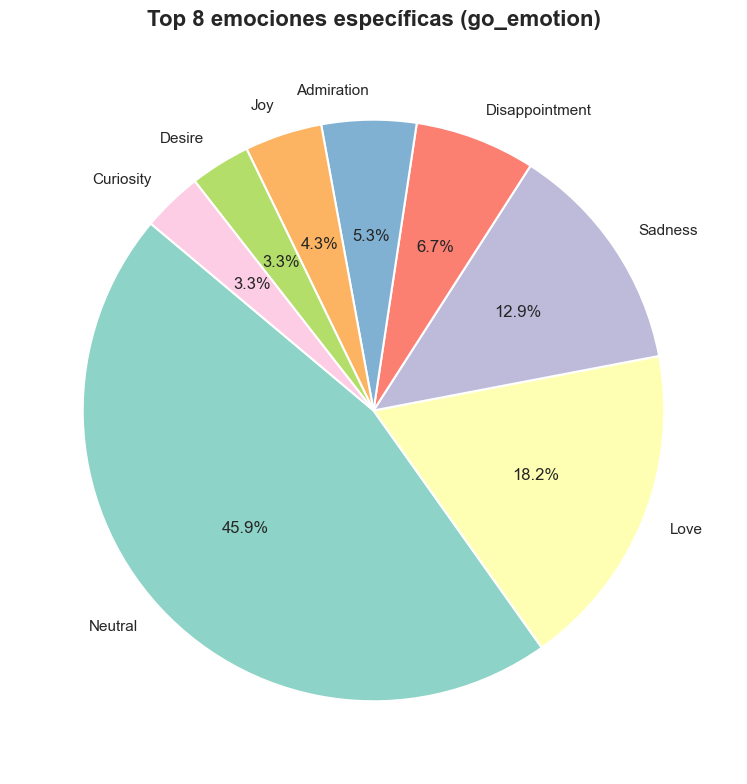

In [27]:
plt.figure(figsize=(8, 8))

emotion_count = df_main['emotion_goemotions'].value_counts().head(8)

plt.pie(
    emotion_count,
    labels=emotion_count.index.str.title(),
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("Set3"),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Top 8 emociones específicas (go_emotion)', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### Distribución de temáticas por álbum

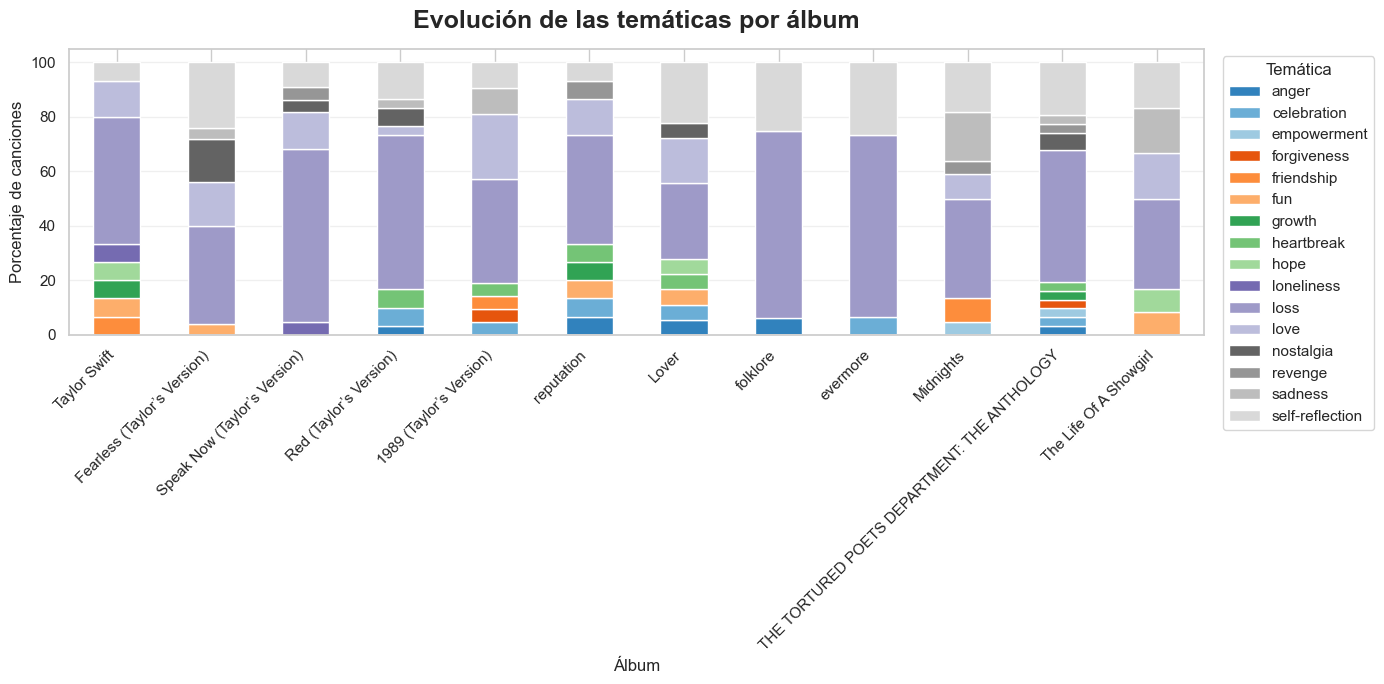

In [28]:
theme_per_album = pd.crosstab(df_main['album'], df_main['theme_zeroshot'], normalize='index') * 100
theme_per_album = theme_per_album.reindex(album_order)

theme_per_album.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='tab20c', edgecolor='white')

plt.title('Evolución de las temáticas por álbum', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Álbum', fontsize=12)
plt.ylabel('Porcentaje de canciones', fontsize=12)
plt.legend(title='Temática', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Nubes de palabras

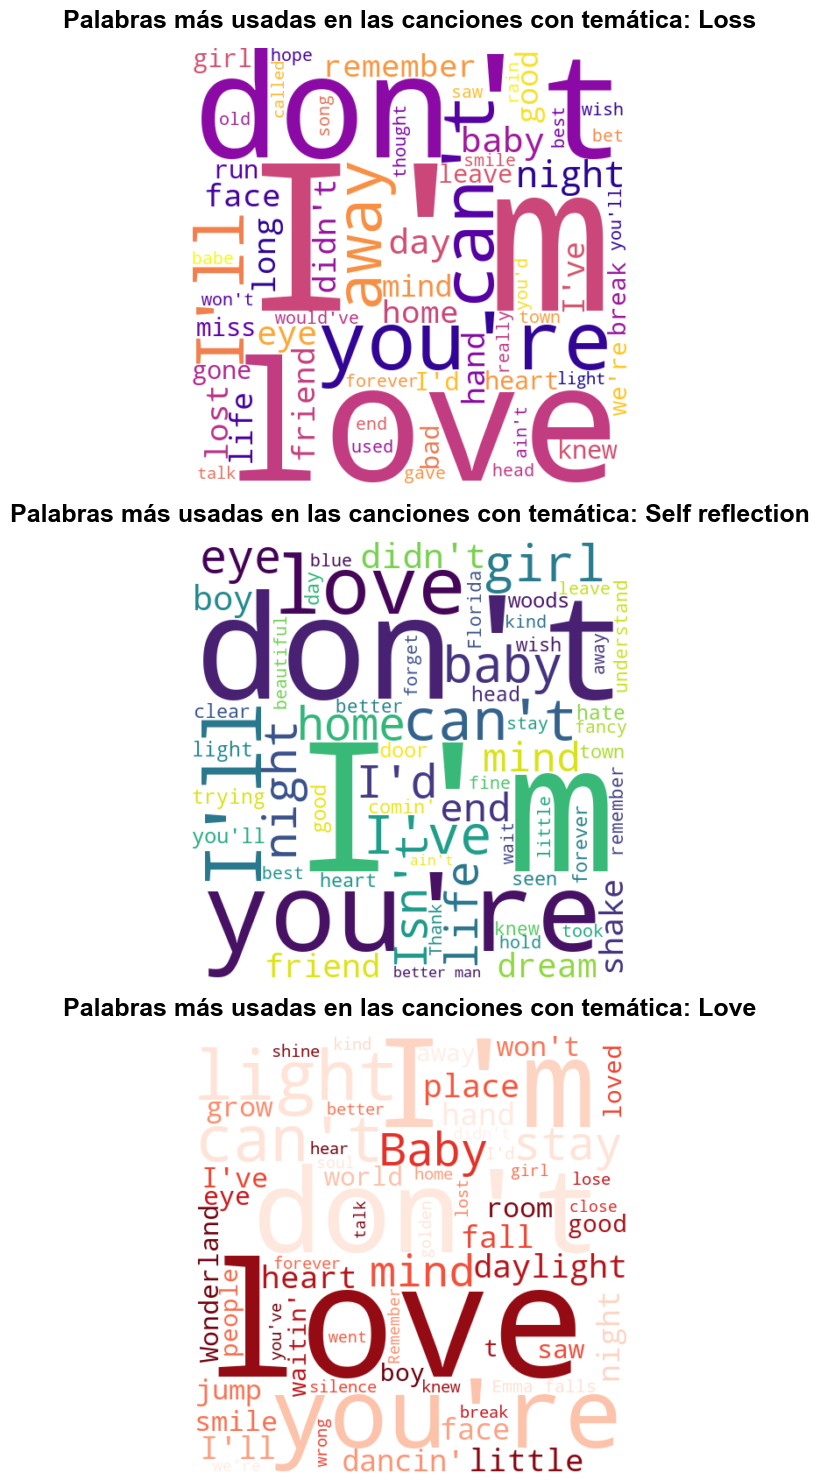

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15))
axes = axes.flatten()

loss_text = " ".join(df_main[df_main['theme_zeroshot'] == 'loss']['lyrics_unique'].dropna().astype(str))
wordcloud_loss = WordCloud(
    width=500, height=500,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=60,
    colormap='plasma'
).generate(loss_text)

axes[0].imshow(wordcloud_loss, interpolation='bilinear')
axes[0].set_title('Palabras más usadas en las canciones con temática: Loss', fontsize=18, fontweight='bold', color='black', pad=15)
axes[0].axis('off')

self_reflection_text = " ".join(df_main[df_main['theme_zeroshot'] == 'self-reflection']['lyrics_unique'].dropna().astype(str))
wordcloud_self_reflection = WordCloud(
    width=500, height=500,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=60,
    colormap='viridis'
).generate(self_reflection_text)

axes[1].imshow(wordcloud_self_reflection, interpolation='bilinear')
axes[1].set_title('Palabras más usadas en las canciones con temática: Self reflection', fontsize=18, fontweight='bold', color='black', pad=15)
axes[1].axis('off')

love_text = " ".join(df_main[df_main['theme_zeroshot'] == 'love']['lyrics_unique'].dropna().astype(str))
wordcloud_love = WordCloud(
    width=500, height=500,
    background_color='white',
    stopwords=custom_stopwords,
    max_words=60,
    colormap='Reds'
).generate(love_text)

axes[2].imshow(wordcloud_love, interpolation='bilinear')
axes[2].set_title('Palabras más usadas en las canciones con temática: Love', fontsize=18, fontweight='bold', color='black', pad=15)
axes[2].axis('off')

plt.tight_layout()
plt.show()

### 4.8 Impacto de la segmentación estructural en el reconocimiento de emociones
Como se puede observar en los siguientes gráficos, inyectar la letra completa en el Transformer tiende a suavizar las emociones, favoreciendo una clasificación "Neutral" genérica. Sin embargo, al segmentar la canción por su estructura real mediante técnicas iterativas, afloran las emociones subyacentes, demostrando que el contexto local es vital para un análisis preciso.

C:\Users\andre\AppData\Local\Temp\ipykernel_29116\3469186220.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotions_goemotion.values, y=emotions_goemotion.index, ax=axes[0], palette="Blues_r")
C:\Users\andre\AppData\Local\Temp\ipykernel_29116\3469186220.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotions_genius.values, y=emotions_genius.index, ax=axes[1], palette="Purples_r")


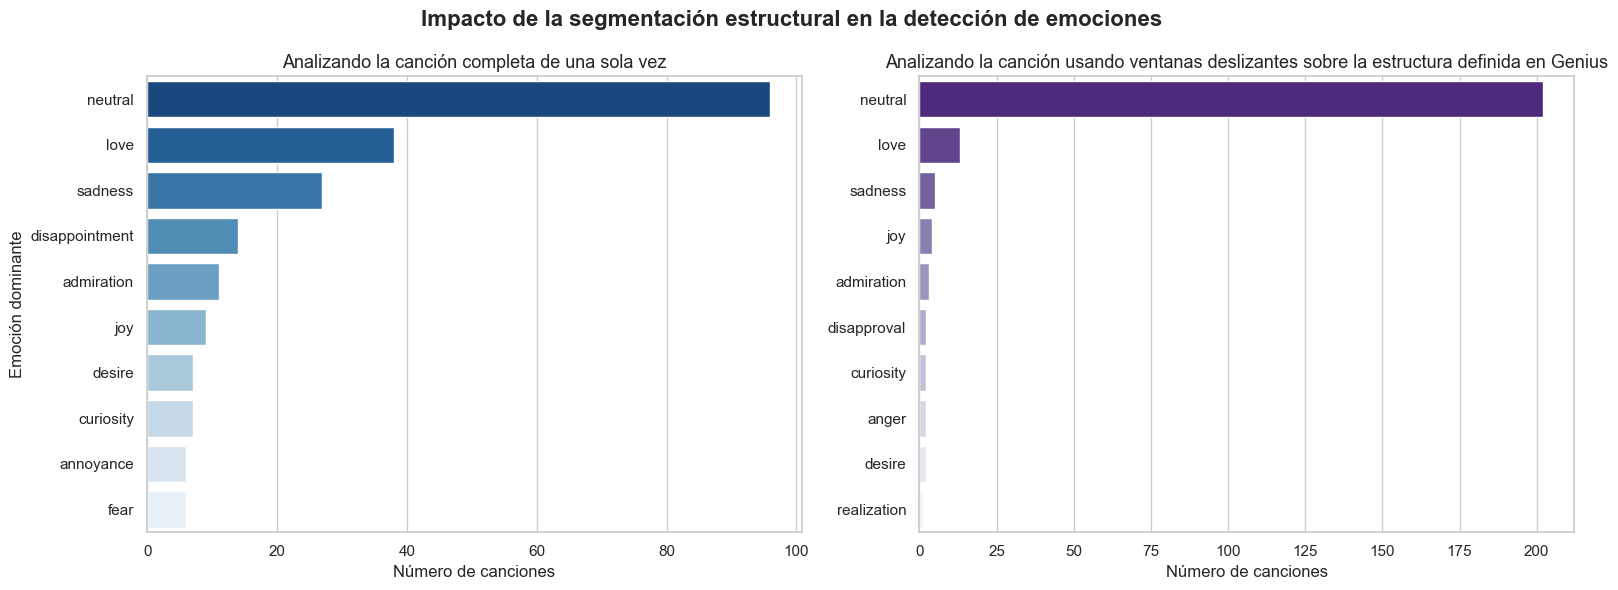

In [30]:
emotions_goemotion = df['emotion_goemotions'].value_counts().head(10)
emotions_genius = df['emotion_genius'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Impacto de la segmentación estructural en la detección de emociones", fontsize=16, fontweight='bold')

sns.barplot(x=emotions_goemotion.values, y=emotions_goemotion.index, ax=axes[0], palette="Blues_r")
axes[0].set_title("Analizando la canción completa de una sola vez", fontsize=13)
axes[0].set_xlabel("Número de canciones")
axes[0].set_ylabel("Emoción dominante")

sns.barplot(x=emotions_genius.values, y=emotions_genius.index, ax=axes[1], palette="Purples_r")
axes[1].set_title("Analizando la canción usando ventanas deslizantes sobre la estructura definida en Genius", fontsize=13)
axes[1].set_xlabel("Número de canciones")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 4.9 Visualización de la estilometría y emoción dinámica
Finalmente, se validó la herramienta de "arco narrativo". Esta visualización cruza la evolución matemática del *Type-Token Ratio* con el mapa de colores de las emociones, bloque por bloque.

Esta técnica permite al usuario final observar, por ejemplo, cómo una canción puede comenzar con un vocabulario complejo y triste en el primer verso, y derivar hacia un estribillo de vocabulario sencillo pero de alta intensidad emocional.

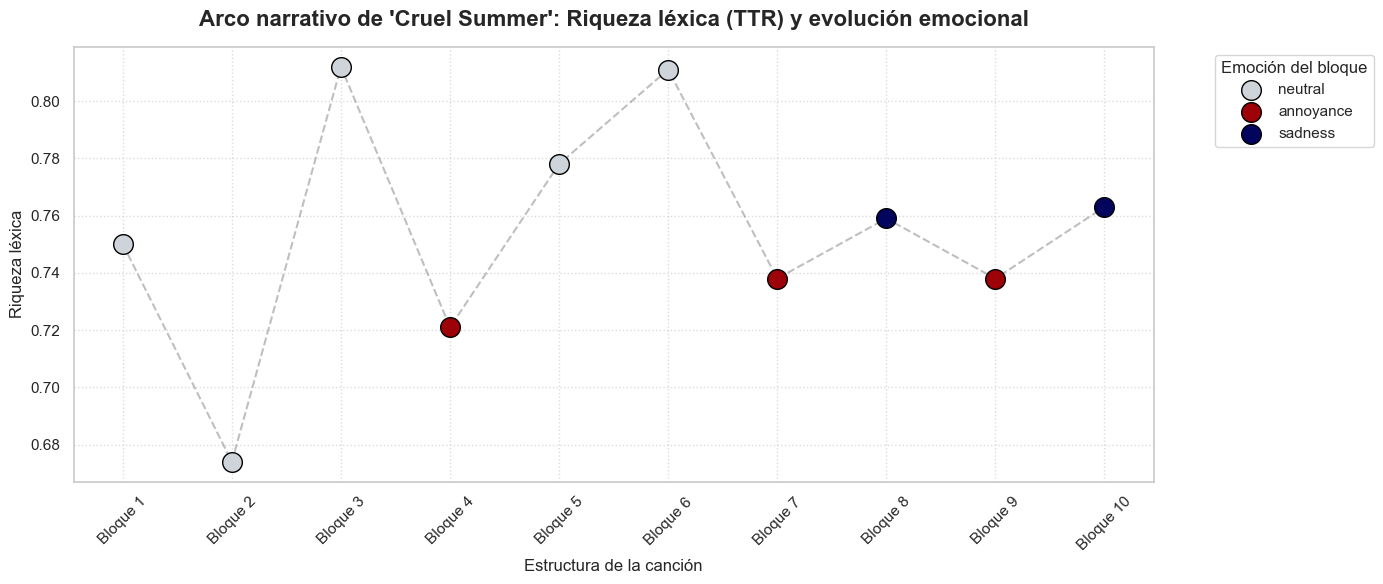

In [31]:
colors = {"admiration": "#9d4edd", "amusement": "#ff9f1c", "anger": "#d00000", 
          "annoyance": "#9d0208", "approval": "#06d6a0", "caring": "#ffb5a7", 
          "confusion": "#5a189a", "curiosity": "#00b4d8", "desire": "#9e2a2b", 
          "disappointment": "#5c677d", "disapproval": "#6a994e", "disgust": "#386641", 
          "embarrassment": "#e5989b", "excitement": "#ff6b35", "fear": "#2b2d42", 
          "gratitude": "#48cae4", "grief": "#14213d", "joy": "#ffd700", "love": "#f72585", 
          "nervousness": "#8d99ae", "optimism": "#8cb369", "pride": "#4361ee", 
          "realization": "#0077b6", "relief": "#ade8f4", "remorse": "#7f4f24", 
          "sadness": "#03045e", "surprise": "#00f5d4", "neutral": "#ced4da"}

song = "Cruel Summer"
verse = df[df['title'] == song].iloc[0]

emotion_seq = json.loads(verse['emotion_genius_seq'])
ttr_seq = json.loads(verse['ttr_genius_seq'])

x = [f"Bloque {i+1}" for i in range(len(ttr_seq))]

plt.figure(figsize=(14, 6))

plt.plot(x, ttr_seq, color='gray', linestyle='--', zorder=1, alpha=0.5)

emotions = set()
for i in range(len(x)):
    emotion = emotion_seq[i]
    color = colors.get(emotion, "#ced4da")

    label = emotion if emotion not in emotions else ""
    plt.scatter(x[i], ttr_seq[i], color=color, s=200, zorder=2, label=label, edgecolor='black')
    emotions.add(emotion)

plt.title(f"Arco narrativo de '{song}': Riqueza léxica (TTR) y evolución emocional", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Estructura de la canción", fontsize=12)
plt.ylabel("Riqueza léxica", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.7)

plt.legend(title="Emoción del bloque", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()